In [15]:
import pandas as pd 
import numpy as np
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
import calendar


MIN_SUPPORT = .03
MIN_CONFIDENCE = .3
save = True

if save:
        with open("data/supp.tex", "w") as f:
                f.write("{:,}".format(MIN_SUPPORT))
        with open("data/conf.tex", "w") as f:
                f.write("{:,}".format(MIN_CONFIDENCE))


In [16]:
avalanches = pd.read_csv('avalanche-record-CAIC.csv')

avalanches = avalanches.drop(['Secondary Trigger','Landmark',"First Name","Last Name","Avg Width", "Locked", "Weak Layer", "Width Units", "Avg Vertical", "Vertical Units", "Avg Crown","Crown Units", "Terminus", "Date Known", "Status", "Description", "Comments","Sliding Sfc", "Location", "Observation ID", "Longitude", "latitude"],axis= 1)


for col in avalanches.select_dtypes(include=["object", "string"]):
    avalanches[col] = avalanches[col].str.strip()#set empty values to NA
avalanches = avalanches.replace(to_replace=["-", "--", "---"], value = pd.NA)

avalanches["Month"] = pd.to_datetime(avalanches["Date"]).dt.month
avalanches["Relative Size"] = avalanches["Relative Size"].replace(to_replace = ["U", "Un"], value = pd.NA)
avalanches["Destructive Size"] = avalanches["Destructive Size"].replace(to_replace = ["U", "Unkn"], value = pd.NA)
avalanches["Elevation"] = avalanches["Elevation"].replace("U",pd.NA)
avalanches["Aspect"] = avalanches["Aspect"].replace("U",pd.NA)
avalanches["Type"] = avalanches["Type"].replace("U",pd.NA)

cols = ["Elevation", "Aspect", "Type", "Destructive Size", "Area", "Month"]
avalanches = avalanches[avalanches[cols].isna().sum(axis=1) <= 3]


def Dmap(value):
    if pd.isna(value):
        return pd.NA
    elif value in ["D1", "D1.5"]:
        return "S"
    elif value in ["D2"]: 
        return "M"
    else:
        return "L"
        

avalanches["Size"] = avalanches["Destructive Size"].map(Dmap)


dataSize = avalanches.shape[0]
if save:
    with open("data/rows.tex", "w") as f:
            f.write("{:,}".format(dataSize))


In [17]:
def transactionMaker(df,cols):
    transactions = df.apply(
    lambda row: {
        f"{col}_{row[col]}"
        for col in cols
        if pd.notna(row[col])
    },
    axis=1).tolist()
    transactionCleaner(transactions)
    return transactions


def transactionCleaner(tran):

    for i in tran:
        if "Elevation_All" in i:
            i.remove("Elevation_All")
            i.add("Elevation_TL")
            i.add("Elevation_<TL")
            i.add("Elevation_>TL")
        if "Aspect_All" in i:
            i.add("Elevation_E")
            i.add("Elevation_NE")
            i.add("Elevation_N")
            i.add("Elevation_SE")
            i.add("Elevation_W")
            i.add("Elevation_NW")
            i.add("Elevation_S")
            i.add("Elevation_SW")

transactions =  transactionMaker(avalanches,["Elevation", "Aspect", "Type", "Size", "Area", "Month"])
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)
frequent_itemsets = apriori(df_encoded, min_support=MIN_SUPPORT, use_colnames=True)
print("Total Frequent Itemsets:", frequent_itemsets.shape[0])
frequent_itemsets= frequent_itemsets.sort_values("support", ascending=False)
numFrequent = frequent_itemsets.shape[0]



Total Frequent Itemsets: 282


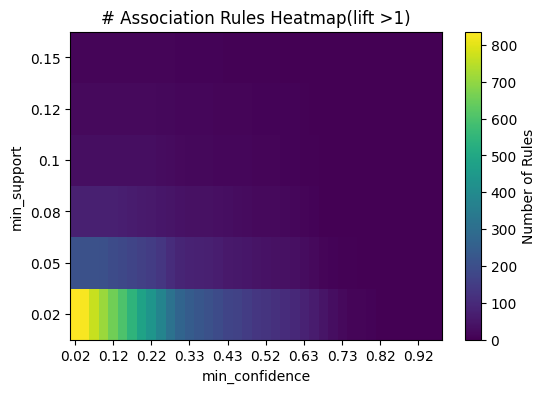

In [18]:
#heatmap
step = .025

suppVals,confVals = np.arange(0.025,1,step),np.arange(0.025,1,step)

n = len(suppVals)
heatmap = np.zeros((n, n))
endSupp = 1
numItemsets = [0] * n

for i in range(n):
    frequent_itemsetsa = apriori(df_encoded, min_support=suppVals[i], use_colnames=True)
    
    if frequent_itemsetsa.shape[0] < 20 :
        endSupp = i
        break
    numItemsets[i] = frequent_itemsetsa.shape[0]
    for j in range(n):


        rulesa = association_rules(frequent_itemsetsa, metric="confidence", min_threshold=confVals[j])
        rulesa = rulesa[rulesa['antecedents'].apply(lambda x: len(x) >= 1) & rulesa['consequents'].apply(lambda x: len(x) >= 1)]
        
        heatmap[i, j] = rulesa[rulesa["lift"] > 1].shape[0]

heatmap = heatmap[:endSupp]
suppVals2 = suppVals[:endSupp]

plt.figure(figsize= (6,4))
plt.imshow(heatmap, aspect='auto',origin='lower')
plt.colorbar(label='Number of Rules')

plt.xticks(
    ticks=np.arange(0, len(confVals), 4),
    labels=np.round(confVals[::4], 2)
)
plt.yticks(ticks=np.arange(len(suppVals2)), labels=np.round(suppVals2, 2))

plt.xlabel('min_confidence')
plt.ylabel('min_support')

plt.title('# Association Rules Heatmap(lift >1)')
if save:
    plt.savefig("images/heatmap.png")
plt.show()


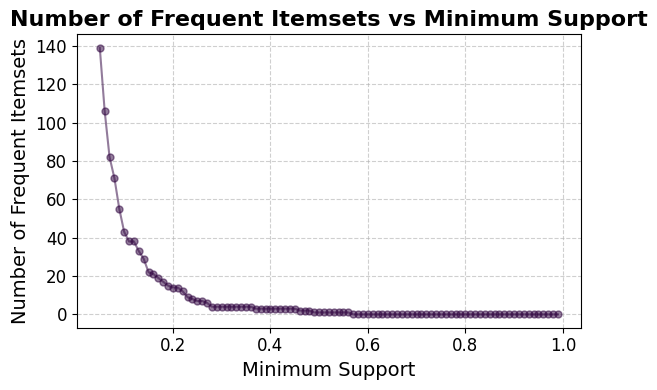

In [19]:
#itemsets
step = 0.01
suppVals = np.arange(0.05, 1, step)

numItemsets = []

# Compute number of frequent itemsets for each min_support
for s in suppVals:
    frequent_itemsetsa = apriori(df_encoded, min_support=s, use_colnames=True)
    numItemsets.append(frequent_itemsetsa.shape[0])

# Plot
plt.figure(figsize=(6,4))
plt.plot(suppVals, numItemsets, marker='o', linestyle='-', color="#32074287", markersize=5)
plt.title("Number of Frequent Itemsets vs Minimum Support", fontsize=16, weight='bold')
plt.xlabel("Minimum Support", fontsize=14)
plt.ylabel("Number of Frequent Itemsets", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
if save:
    plt.savefig("images/itemsets.png")
plt.show()



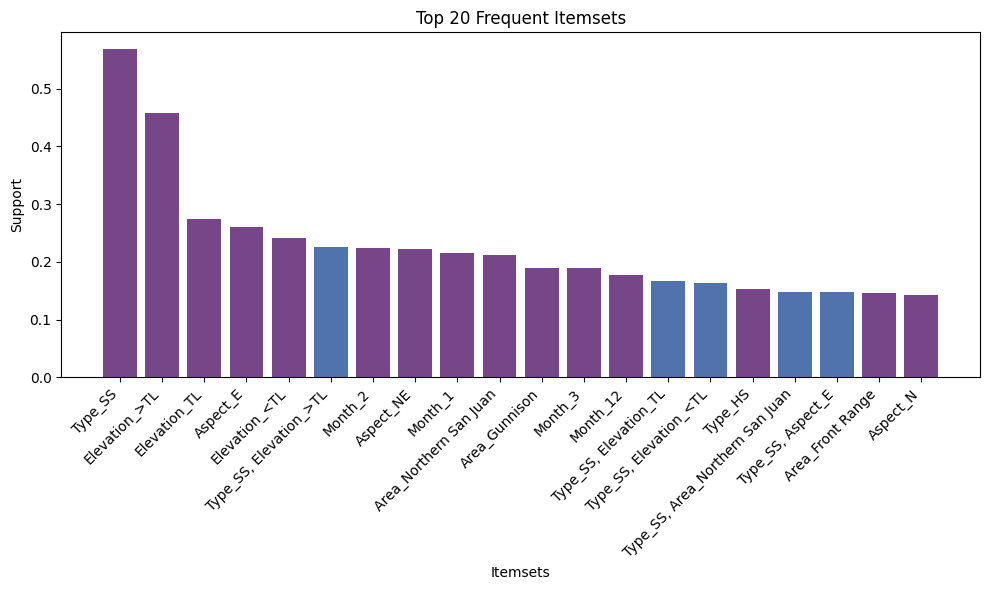

In [20]:
N =20
conditionsTransactions =  transactionMaker(avalanches,["Elevation", "Aspect", "Area", "Month","Type"])
te3 = TransactionEncoder()
te_array3 = te3.fit(conditionsTransactions).transform(conditionsTransactions)
df_encoded3 = pd.DataFrame(te_array3, columns=te3.columns_)
frequent_conditions= apriori(df_encoded3, min_support=MIN_SUPPORT, use_colnames=True)

frequent_conditions["length"] = frequent_conditions["itemsets"].apply(len)
frequent_conditions= frequent_conditions.sort_values("support", ascending=False)


labels = frequent_conditions["itemsets"][:N].apply(lambda x: ", ".join(list(x)))
values = frequent_conditions["support"][:N]
lengths = frequent_conditions["length"][:N]
unique_lengths = sorted(lengths.unique())

def colo(length):
    color_map = {
        1: "#4A0962C0", 
        2: "#12408FBB"   
    }
    return color_map.get(length)  

colors = frequent_conditions["length"][:N].apply(colo)

plt.figure(figsize=(10,6))
plt.bar(labels, values, color= colors)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Itemsets")
plt.ylabel("Support")
plt.title(f"Top {N} Frequent Itemsets")
plt.tight_layout()
if save:
    plt.savefig("images/allItemset_support.png")

plt.show()



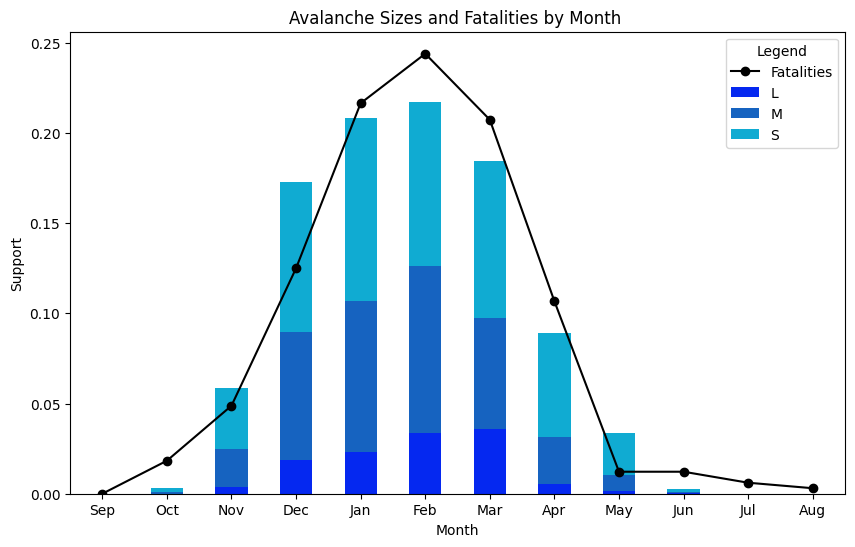

In [21]:
counts = avalanches.groupby(["Month", "Size"]).size().unstack(fill_value=0)
counts = counts.sort_index() / dataSize
counts = counts.loc[:, ["L", "M", "S"]]

accidents = pd.read_excel('CAIC_Accident_Data.xlsx')
accidents = accidents.drop([
    "AvyYear", "YYYY", "DD", "Date", "Location", "Setting",
    "lat", "lon", "TravelMode", "Description", "PrimaryActivity"
], axis=1)

accidents = accidents[accidents["State"] == "CO"]
accidents = accidents.rename(columns={"MM": "Month"})
    
fatalities = accidents.groupby("Month").agg(
    Total_Fatalities=('Killed', 'sum')
)

fatalities = fatalities / fatalities.sum()

month_order = [9,10,11,12,1,2,3,4,5,6,7,8]

counts = counts.reindex(month_order)
fatalities = fatalities.reindex(month_order,fill_value=0)

counts.index = [calendar.month_abbr[m] for m in counts.index]
fatalities.index = [calendar.month_abbr[m] for m in fatalities.index]

colors = ["#0528f0", "#1663c0", "#10ABD2"]

fig, ax1 = plt.subplots(figsize=(10, 6))

counts.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax1
)

ax1.plot(
    range(len(fatalities)),
    fatalities["Total_Fatalities"],
    color="black",
    label="Fatalities",
    zorder=5,
    marker = 'o'
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Support")
ax1.set_title("Avalanche Sizes and Fatalities by Month ")

ax1.set_xticks(range(len(counts.index)))
ax1.set_xticklabels(counts.index, rotation=0)

handles1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(handles1, labels1 , title="Legend",loc="upper right")

if save:
    plt.savefig("images/combined_plot.png")
plt.show()


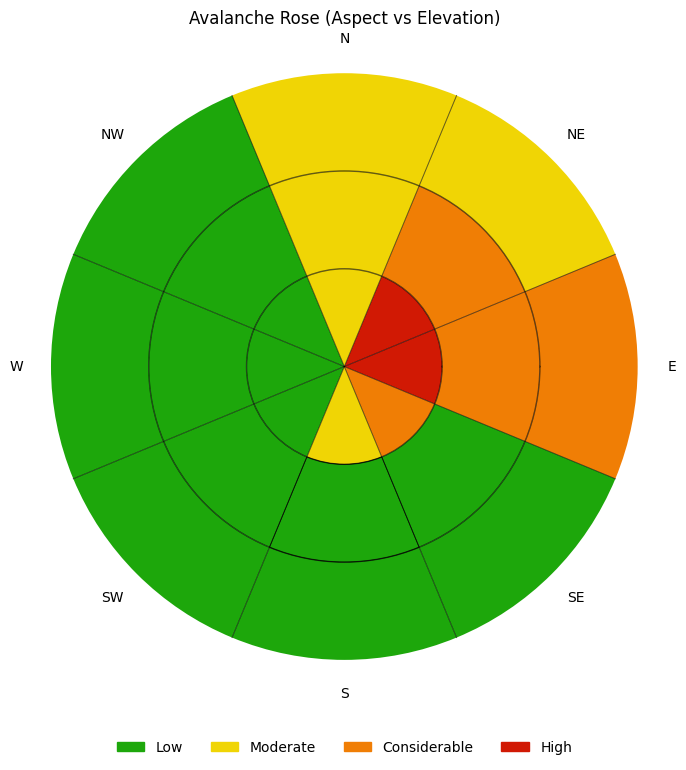

dict_items([(('E', '>TL'), 1.0), (('SE', '>TL'), 0.7021651560926485), (('NE', '<TL'), 0.4786002014098691), (('NE', '>TL'), 0.7555387713997985), (('E', 'TL'), 0.573766364551863), (('NE', 'TL'), 0.562185297079557), (('E', '<TL'), 0.5342396777442094), (('NW', '>TL'), 0.21047331319234644), (('NW', 'TL'), 0.1603726082578046), (('N', '<TL'), 0.303877139979859), (('SE', 'TL'), 0.2472306143001007), (('W', '>TL'), 0.19159113796576033), (('SW', '>TL'), 0.1565961732124874), (('W', 'TL'), 0.12739174219536756), (('SE', '<TL'), 0.1500503524672709), (('W', '<TL'), 0.18580060422960723), (('S', '>TL'), 0.27316213494461233), (('SW', 'TL'), 0.062185297079556896), (('N', 'TL'), 0.41389728096676737), (('NW', '<TL'), 0.16289023162134947), (('N', '>TL'), 0.42421953675730106), (('S', '<TL'), 0.06168177240684793), (('SW', '<TL'), 0.04481369587109768), (('S', 'TL'), 0.08006042296072508), (('All', 'S'), 0.026435045317220542)])


In [22]:
aspectElevation = transactionMaker(avalanches,["Aspect","Elevation"])
counts = defaultdict(int)

for itemset in aspectElevation:
    aspect = None
    elevation = None

    for item in itemset:
        if item.startswith("Aspect_"):
            aspect = item.replace("Aspect_", "")
        elif item.startswith("Elevation_"):
            elevation = item.replace("Elevation_", "")

    if aspect and elevation:
        counts[(aspect, elevation)] += 1


max_count = max(counts.values())
total= len(aspectElevation)
counts = {k: v / total for k, v in counts.items()}
max_count = max(counts.values())
counts = {k: v / max_count for k, v in counts.items()}

aspect_angles = {
    "N": np.pi/2,
    "NE": np.pi/4,
    "E": 0,
    "SE": 7*np.pi/4,
    "S": 3*np.pi/2,
    "SW": 5*np.pi/4,
    "W": np.pi,
    "NW": 3*np.pi/4
}

elevation_levels = {
    "<TL": 2,
    "TL": 1,
    ">TL": 0
}
def get_color(val):
    if val < 0.25:
        return "#1da70b" 
    elif val < 0.5:
        return "#f0d505" 
    elif val < 0.75:
        return "#f07e05" 
    else:
        return "#d11904" 



fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

width = np.pi / 4

for (aspect, elevation), val in counts.items():
    if aspect not in aspect_angles or elevation not in elevation_levels:
        continue

    angle = aspect_angles[aspect]
    base = elevation_levels[elevation]

    color = get_color(val)

    ax.bar(angle, 1, width=width, bottom=base, color=color)

legend_patches = [
    mpatches.Patch(color="#1da70b", label="Low"),
    mpatches.Patch(color="#f0d505", label="Moderate"),
    mpatches.Patch(color="#f07e05", label="Considerable"),
    mpatches.Patch(color="#d11904", label="High"),
]



ax.legend(handles=legend_patches, loc='lower center',
          bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False)

ax.set_yticks([0, 1, 2])
ax.set_yticklabels([])
ax.yaxis.grid(True, linewidth=1, color='black', alpha=0.6)
ax.spines['polar'].set_visible(False)


ax.set_xticks(list(aspect_angles.values()))
ax.set_xticklabels(list(aspect_angles.keys()))
ax.xaxis.grid(False)
ax.set_title("Avalanche Rose (Aspect vs Elevation)")
ax.bar(angle, 1, width=width, bottom=base, color=color, edgecolor='black', linewidth=0.5, alpha=0.9)
boundary_angles = [angle + width/2 for angle in aspect_angles.values()]
for angle in boundary_angles:
    ax.plot([angle, angle], [0, 3],
            color='black', linewidth=0.7, alpha=0.6)
    
if save:
    plt.savefig("images/rose.png")
plt.show()
print(counts.items())

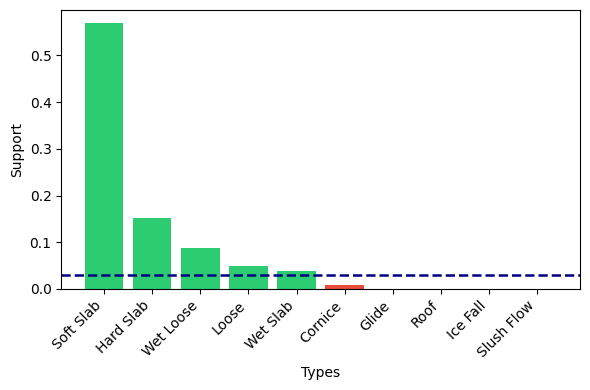

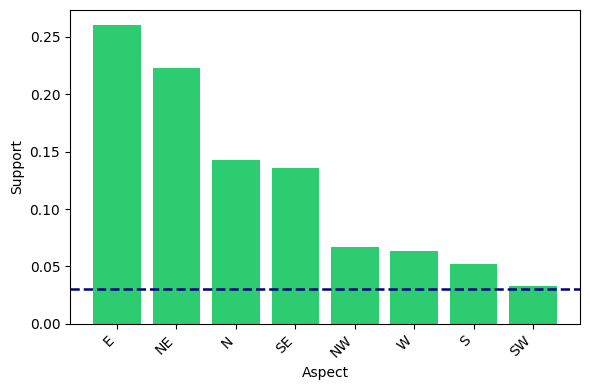

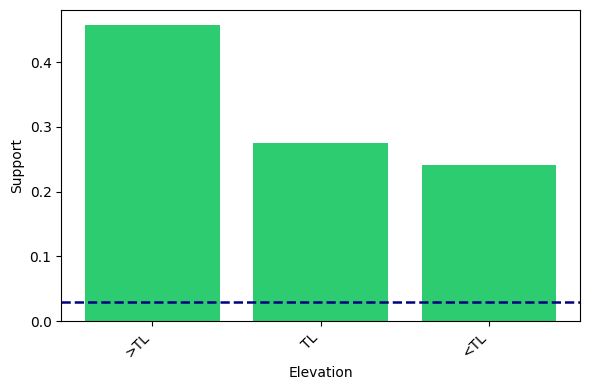

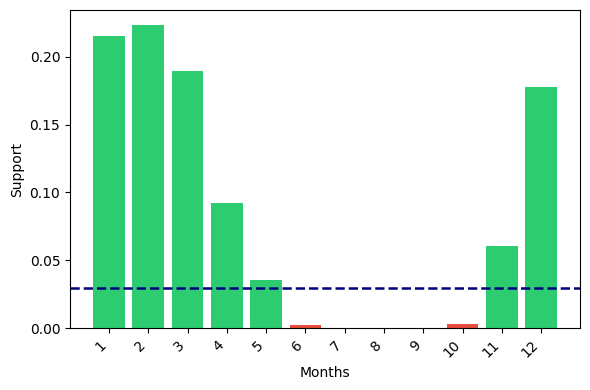

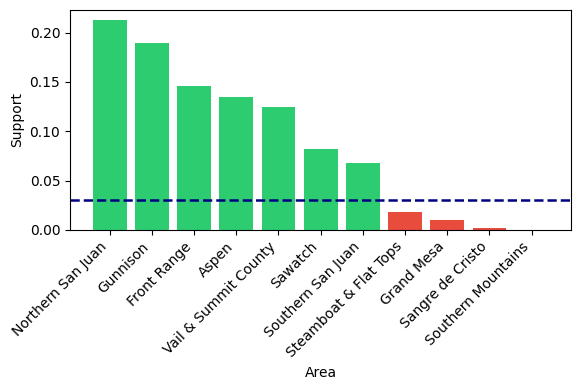

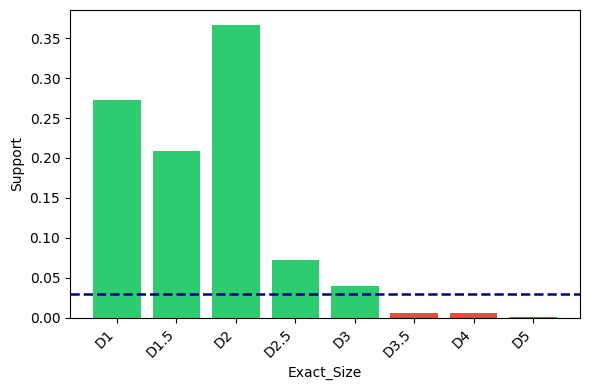

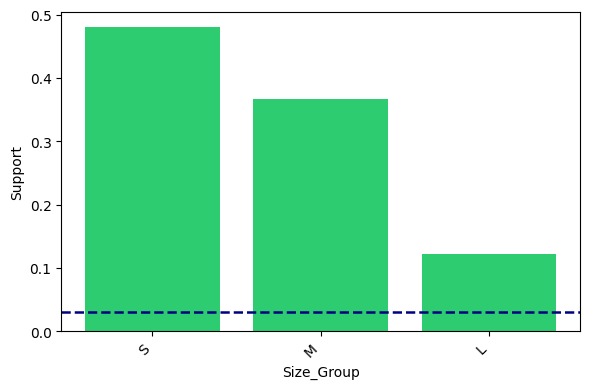

In [23]:
transactions2 = transactionMaker(avalanches, ["Elevation", "Aspect", "Type", "Destructive Size", "Area", "Month", "Size"])



types = [{f"Type_{ele}"} for ele in avalanches["Type"].dropna().unique()]
# triggers = [{f"Trigger_{ele}"} for ele in avalanches["Trigger"].dropna().unique()]

aspects = [{f"Aspect_{ele}"} for ele in avalanches["Aspect"].dropna().unique() if ele != "All"]
elevations = [{"Elevation_TL"},{"Elevation_<TL"},{"Elevation_>TL"}]
months = [{f"Month_{int(ele)}"} for ele in sorted(avalanches["Month"].dropna().unique(), key=int)]
Area = [{f"Area_{ele}"} for ele in sorted(avalanches["Area"].dropna().unique())]
Size= [{f"Destructive Size_{ele}"} for ele in sorted(avalanches["Destructive Size"].dropna().unique())]
SizeD= [{f"Size_{ele}"} for ele in sorted(avalanches["Size"].dropna().unique())]


type_map = {
    "Type_WS": "Wet Slab",
    "Type_WL": "Wet Loose",
    "Type_HS": "Hard Slab",
    "Type_SS": "Soft Slab",
    "Type_C": "Cornice",
    "Type_L": "Loose",
    "Type_G": "Glide",
    "Type_R": "Roof",
    "Type_I": "Ice Fall",
    "Type_SF": "Slush Flow"
}
def compute_support(candidates, tran):

    n = len(tran)
    sol = {}
    for c in candidates:
        count = 0
        for t in tran:
            if c.issubset(t):
                count += 1
        sol[frozenset(c)] = count/n

    return sol


def computePlot(items,xl,sort = True, label_map = None):

    support = compute_support(items, transactions2)
    if(sort):
        sorted_items = sorted(support.items(), key=lambda x: x[1], reverse=True)
    else:
        sorted_items = sorted(support.items(), key=lambda x: x[0], reverse=True)

    labels = []
    for k, _ in sorted_items:
        parts = []
        for s in k:
            if label_map and s in label_map:
                parts.append(label_map[s])
            else:
                parts.append(s.split('_', 1)[1]) 
        labels.append('+'.join(parts))

    values = [v for _, v in sorted_items]
    colors = ['#2ecc71' if v >= MIN_SUPPORT else '#e74c3c' for v in values]
    plt.figure(figsize=(6,4))
    
    plt.axhline(MIN_SUPPORT, color='navy', linestyle='--', linewidth=1.8, label=f'min_support = {MIN_SUPPORT}')

    plt.bar(labels, values, color = colors)
    plt.xticks(ticks=np.arange(len(values)), labels=labels, rotation=45, ha='right')
    plt.xlabel(xl)
    plt.ylabel("Support")
    plt.tight_layout()
    if save:
        plt.savefig(f"images/{xl}_support.png")
    plt.show()

computePlot(types, "Types", label_map= type_map)
computePlot(aspects, "Aspect")
computePlot(elevations, "Elevation")
computePlot(months, "Months", False)
computePlot(Area, "Area")
computePlot(Size, "Exact_Size", False)
computePlot(SizeD, "Size_Group")



In [24]:
#association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=MIN_CONFIDENCE)
rules = rules[rules['antecedents'].apply(lambda x: len(x) >= 1) & rules['consequents'].apply(lambda x: len(x) >= 1)]
rules = rules[rules["lift"] > 1]
numRules = rules.shape[0]
print("Association Rules:", numRules)
rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values("lift",ascending = False)
if save:
    with open("data/rules.tex", "w") as f:
            f.write("{:,}".format(numRules))


Association Rules: 212


In [25]:
#tables of asssociation rules
def texReplace(dfs):
    rlist = []
    for df in dfs:
        df = df.copy()

        antecedents = df['antecedents'].apply(", ".join)
        consequents = df['consequents'].apply(", ".join)


        df['rule'] = antecedents + r" $\Rightarrow$ " + consequents

        replacements = {
            '>': r'$>$',
            '<': r'$<$',
            '_': r'\_',
            '&': r'\&'
        }

        df['rule'] = df['rule'].replace(replacements, regex=True)
        rlist.append( df[['rule', 'support', 'confidence', 'lift']])
    return rlist



def rulefilter(anec=None, cons=None):
    return rules[
        rules['antecedents'].apply(
            lambda x: (
                not any("Size" in item for item in x)
                and 
                (
                not anec or
                (
                    len(x) == len(anec) and
                    all(any(a in item for item in x) for a in anec)
                ))
            )
        ) &
        rules['consequents'].apply(
            lambda x: (
                not cons or
                all(any(c in item for c in cons) for item in x)
            )
        )]

overallRules = rulefilter( cons = ["Size","Type"])
rules_ElevationTo = rulefilter(["Elevation"],["Size", "Type"])
rules_AspectTo = rulefilter(["Aspect"],["Size", "Type"])
rules_MonthTo = rulefilter(["Month"],["Size", "Type"])
rules_AreaTo = rulefilter(["Area"],["Size", "Type"])
rules_TypeTo = rulefilter(["Type"],["Size"])
rules_elevAspectTo = rulefilter(["Elevation","Aspect"], ["Size", "Type"])
rules_ToSize =rulefilter(cons = ["Size"])
rules_ToType = rulefilter( cons = ["Type"])



ruleList = [rules_ElevationTo, rules_AspectTo, rules_MonthTo,rules_AreaTo, rules_TypeTo,rules_elevAspectTo,rules_ToSize,rules_ToType]
nList = ["rules_ElevationTo", "rules_AspectTo", "rules_MonthTo","rules_AreaTo", "rules_TypeTo","rules_elevAspectTo","rules_ToSize","rules_ToType"]


def saver(rList,nList,length=None):
    for r,n in zip(rList,nList):
        with open(f"tables/{n}.tex", "w") as f:
            if(length):
                f.write(r[:length].to_latex(index=False))
            else:
                f.write(r[:50].to_latex(index=False))

if save:
    saver(texReplace([overallRules]),["overallRules"],15)
    saver(texReplace(ruleList),nList)

print(len(rules_ToSize))

68
